In [1]:
using LinearAlgebra
using Plots
using QuadGK
using FastGaussQuadrature
using LaTeXStrings
using ProgressMeter
using Dierckx
pgfplotsx() # pgfplotsx() or gr()
default(
    fontfamily = "Computer Modern",
    tickfont   = font(15, "Computer Modern"),
    guidefont  = font(15, "Computer Modern"),
    legendfont = font(15, "Computer Modern"),
    lw = 2,
    grid = :on,
    gridalpha = 0.3,
    size = (500, 400),
    legend = :topright,
    framestyle = :box,
    color_palette = palette(:tab10)
)
const address = "/Users/johnreeg/Documents/Repositories/Maris-Tandy/images/";

In [2]:
# Constants
Nf = 4.0
m = 0.0037
w = 0.4
D = 1 # 0.93312
Lambda2 = 1e6
epsilon2 = 1e-4
Lambda_PV = 2e2
Lambda_QCD = 0.234
gamma_m = 0.48 # 12/(33 - 2 * Nf) = 0.48
mu = 19.0
Z_2 = 1
Z_4m = 0.7 * m

# Integration Grids
x, w_x = gausslegendre(200)
z, w_z = gausschebyshevu(40) # Chebyshev second kind
t = 0.5 * (log(Lambda2) - log(epsilon2)) * x .+ 0.5 * (log(Lambda2) + log(epsilon2))
w_t = 0.5 * (log(Lambda2) - log(epsilon2)) * w_x

# Initial Vectors
A = 1.6 * ones(length(t))
B = (m + 1e-3) * ones(length(t));

In [3]:
# Dot Products
pk(p, q, z) = p^2 - p*q*z
qk(p, q, z) = p*q*z - q^2
k2(p, q, z) = p^2 + q^2 - 2*p*q*z

# Stephan called them alpha(k^2)
F_UV(k2) = 2pi * gamma_m * (1 - exp(-k2)) / log(exp(2) - 1 + (1 + k2 / Lambda_QCD^2)^2)
G(k2) = D/w^6 * pi * k2^2 * exp(-k2 / w^2) + F_UV(k2)

# Angular Integrals over z = cos(psi)
function z_intA(p, q)
    K2 = k2.(p, q, z)
    integrand = @. w_z * ( p*q*z + 2*pk(p, q, z)*qk(p, q, z)/K2 ) * G(K2) / K2 * Lambda_PV^2 / (K2 + Lambda_PV^2)
    return sum(integrand)
end

function z_intB(p, q)
    K2 = k2.(p, q, z)
    integrand = @. w_z * G(K2) / K2 * Lambda_PV^2 / (K2 + Lambda_PV^2)
    return sum(integrand)
end;

In [4]:
# Final Radial Integrals
function Sigma_A(p2, A, B, Z_2)
    integrand = @. w_t * exp(2*t) * A / (exp(t) * A^2 + B^2) * z_intA(sqrt(p2), exp(t/2))
    return Z_2^2 * 16pi/(3*(2pi)^3 * p2) * sum(integrand)
end

function Sigma_B(p2, A, B, Z_2)
    integrand = @. w_t * exp(2*t) * B / (exp(t) * A^2 + B^2) * z_intB(sqrt(p2), exp(t/2))
    return Z_2^2 * 16pi/(2pi)^3 * sum(integrand)
end;

In [5]:
# Iteration Step Function
function update(A, B, Z_2, Z_4m)
    A_int = Z_2 .+ Sigma_A.(exp.(t), Ref(A), Ref(B), Z_2)
    B_int = Z_4m .+ Sigma_B.(exp.(t), Ref(A), Ref(B), Z_2)
    max_A = maximum(abs.(A .- A_int))
    max_B = maximum(abs.(B .- B_int))
    Z_2  = 1 - Sigma_A(mu^2, A, B, Z_2)
    Z_4m = m - Sigma_B(mu^2, A, B, Z_2)
    # alpha = 0.5
    # return alpha .* A_int .+ (1-alpha) .* A, alpha .* B_int .+ (1-alpha) .* B, max(max_A, max_B)
    return A_int, B_int, Z_2, Z_4m, max(max_A, max_B)
end;

In [6]:
# Iteration Loop
max_iter = 100
p = Progress(max_iter, desc = "Berechne...")

for i in 1:max_iter
    A, B, Z_2, Z_4m, max_error = update(A, B, Z_2, Z_4m)
    next!(p)
    if max_error < 1e-8
        println("Finished: i = ", i)
        break
    end
    if i == max_iter
        throw(error("Failed: max_error = ", max_error))
    end
end

Berechne...  48%|███████████████████▎                    |  ETA: 0:00:47

Finished: i = 48


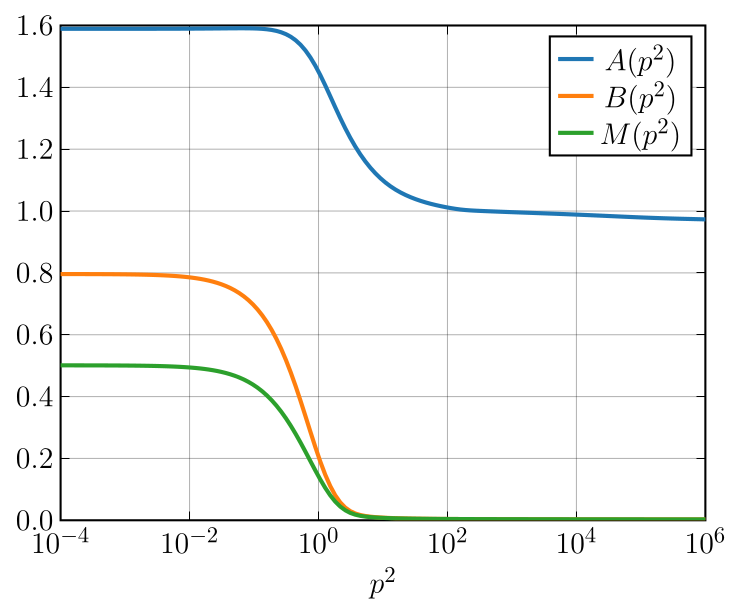

In [7]:
# Plots
plot(exp.(t), A, xaxis=:log10, xlims = (epsilon2, Lambda2), ylims = (0, 1.6), yticks = 0:0.2:1.6, label = L"A(p^2)", xlabel = L"p^2") # \; \left[\mathrm{GeV}^2\right]
plot!(exp.(t), B, label = L"B(p^2)")
plot!(exp.(t), B./A, label = L"M(p^2)")
# savefig(address * "D1.pdf"); plot!()
# plot!()

In [8]:
A_spline = Spline1D(exp.(t), A, k = 3)
B_spline = Spline1D(exp.(t), B, k = 3);

In [35]:
function z_interpA(p, q)
    integrand(z) = sqrt(1-z^2) * ( p*q*z + 2*pk(p, q, z)*qk(p, q, z)/k2(p, q, z) ) * G(k2(p, q, z)) / k2(p, q, z) * Lambda_PV^2 / (k2(p, q, z) + Lambda_PV^2)
    return quadgk(integrand, -1, 1)[1]
end

function z_interpB(p, q)
    integrand(z) = sqrt(1-z^2) * G(k2(p, q, z)) / k2(p, q, z) * Lambda_PV^2 / (k2(p, q, z) + Lambda_PV^2)
    return quadgk(integrand, -1, 1)[1]
end;

function Sigma_A(p2)
    integrand(t) = exp(2*t) * A_spline(exp(t)) / (exp(t) * A_spline(exp(t))^2 + B_spline(exp(t))^2) * z_interpA(sqrt(p2), exp(t/2))
    return Z_2^2 * 16pi/(3*(2pi)^3 * p2) * quadgk(integrand, log(epsilon2), log(Lambda2))[1]
end

function Sigma_B(p2)
    integrand(t) = exp(2*t) * B_spline(exp(t)) / (exp(t) * A_spline(exp(t))^2 + B_spline(exp(t))^2) * z_interpB(sqrt(p2), exp(t/2))
    return Z_2^2 * 16pi/(2pi)^3 * quadgk(integrand, log(epsilon2), log(Lambda2))[1]
end;

In [37]:
# Plots
p2 = Complex.(-10 : 0.02 : 0)

AA = Z_2 .+ Sigma_A.(p2)
BB = Z_4m .+ Sigma_B.(p2)
MM = abs.(BB./AA)
mask = isfinite.(MM) .& (MM .< 1e4)

plot(p2[mask], MM[mask], xlims = (-10, 0), ylims = (0, 1000), label = L"M(p^2)", xlabel = L"p^2") # \; \left[\mathrm{GeV}^2\right]

# plot!(p2, real.(BB), label = L"B(p^2)")
# plot!(p2, real.(AA), label = L"A(p^2)")
# savefig(address * "$(length(t))_$(length(z)).pdf")
# plot!()

LoadError: InterruptException: